# ASNR Graph Classification
Classifying animal social networks by interaction type and biological class using GNNs.

**Structure:**
1. Data loading
2. EDA — structural features, class balance, biological class breakdown
3. Dataset construction (with biological class label stored)
4. Train / val / test split (stratified)
5. Data augmentation (fixed node-drop)
6. GCN model + weighted loss
7. Training with validation monitoring
8. Evaluation — confusion matrix, F1 scores
9. Biological analysis — class × interaction type breakdown
10. Embedding visualisation (UMAP / t-SNE)

## Data Loading

In [10]:
from pathlib import Path
import networkx as nx
import pandas as pd

folder_path = Path('./asnr datasets')
assert folder_path.exists() #if crashing here, fix your filepath / working directory

asnr_graphs = {}
for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)
    asnr_graphs[file_path.stem + '.graphml'] = graph

info_frame = pd.read_csv(folder_path / 'Network_summary_masterfile.csv')


In [4]:
print(f'Loaded {len(asnr_graphs)} graphs')
print("Column Names:")
print(info_frame.columns.tolist())

Loaded 1197 graphs
Column Names:
['Network_ID', 'Network_Identifiers', 'class', 'genus', 'species', 'interaction_type', 'definition_of_interaction', 'edge_wt_type', 'geographical_location', 'population_type', 'data_record_technique', 'time_span', 'resolution', 'time_span_per_day', 'attributes_available', 'is_connected', 'num_components', 'nodes', 'edges', 'network.density', 'highest.degree', 'avg.degree', 'std.degree.node', 'CV.degree', 'skewness', 'avg.node.strength', 'std.node.strength', 'CV.node.strength', 'avg.edge.strength', 'std.edge.strength', 'CV.edge.strength', 'highest.node.strength', 'deg.assort', 'avg.betw.centrality', 'std.betw.centrality', 'highest.betw', 'avg.betw.centrality.weighted', 'std.betw.centrality.weighted', 'highest.betw.weighted', 'clustering', 'clustering.weighted', 'transitivity', 'Q', 'Qmax', 'Qrel', 'cohesion', 'num.modules', 'avg.modsize', 'diameter', 'Citation']


## Exploratory Data Analysis

In [ ]:
print('Biological class counts:')
print(info_frame['class'].value_counts())
print("\n")
print('Interaction type counts:')
print(info_frame['interaction_type'].value_counts())

Biological class counts:
class
Mammalia          560
Insecta           287
Aves              185
Actinopterygii    101
Reptilia           59
Arachnida           2
Amphibia            2
Cephalapoda         1
Name: count, dtype: int64


Interaction type counts:
interaction_type
social_projection_bipartite        343
physical_contact                   271
spatial_proximity                  200
grooming                           136
dominance                          107
FE_mating                           58
non_physical_social_interaction     21
food_sharing                        19
trophallaxis                        16
group_membership                    16
overall_mix                          3
NFE_mating                           3
foraging                             2
Avoidance                            2
Name: count, dtype: int64


In [22]:
# Cross Tabulation
crosstab = pd.crosstab(info_frame['class'], info_frame['interaction_type'])
#print('Graphs per (class, interaction_type):')
#print(crosstab)

crosstab_table = (
    crosstab.style
    .background_gradient(cmap='viridis')
    .set_caption('Graphs per (class, interaction_type)')
)

# If using Jupyter Notebook:
display(crosstab_table)

interaction_type,Avoidance,FE_mating,NFE_mating,dominance,food_sharing,foraging,grooming,group_membership,non_physical_social_interaction,overall_mix,physical_contact,social_projection_bipartite,spatial_proximity,trophallaxis
class,,,,,,,,,,,,,,
Actinopterygii,0,0,0,56,0,0,0,7,0,0,0,0,38,0
Amphibia,0,0,2,0,0,0,0,0,0,0,0,0,0,0
Arachnida,0,1,0,0,0,0,0,0,0,0,1,0,0,0
Aves,0,25,0,28,18,2,19,5,19,0,19,30,20,0
Cephalapoda,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Insecta,0,15,0,0,0,0,0,0,0,0,244,0,12,16
Mammalia,2,16,0,23,1,0,117,4,2,3,7,260,125,0
Reptilia,0,1,0,0,0,0,0,0,0,0,0,53,5,0


#### Also show in matplotlib

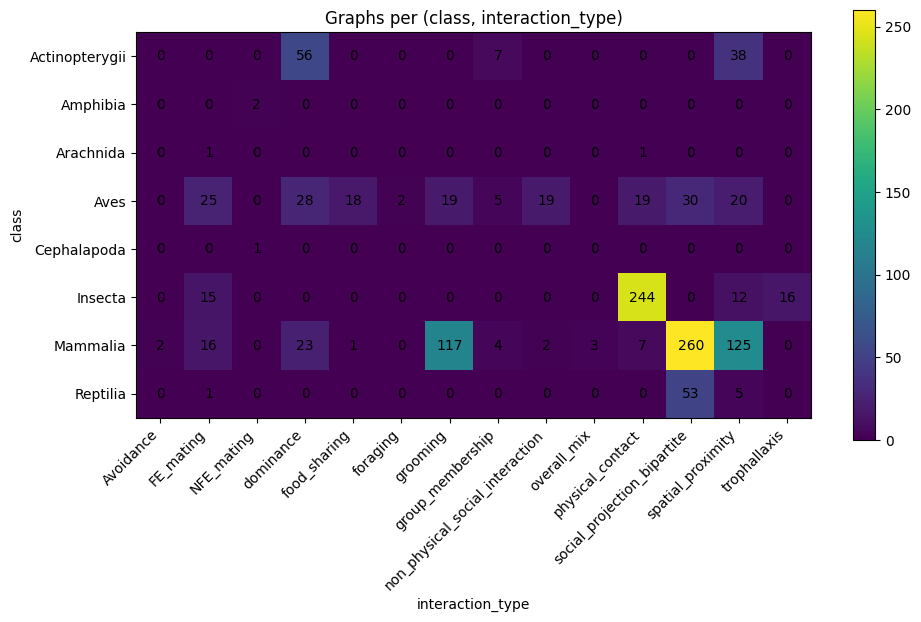

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(crosstab.values)

# Axis labels
ax.set_xticks(range(len(crosstab.columns)))
ax.set_xticklabels(crosstab.columns, rotation=45, ha='right')

ax.set_yticks(range(len(crosstab.index)))
ax.set_yticklabels(crosstab.index)

# Add cell values
for i in range(len(crosstab.index)):
    for j in range(len(crosstab.columns)):
        ax.text(
            j, i,
            crosstab.iloc[i, j],
            ha='center',
            va='center'
        )

# Titles
ax.set_title('Graphs per (class, interaction_type)')
ax.set_xlabel('interaction_type')
ax.set_ylabel('class')

# Color bar
fig.colorbar(im)

plt.tight_layout()
plt.show()

## Feature Distribution by Biological Class / Interaction Type

In [ ]:
# Structural feature distributions per biological class 
import numpy as np
import matplotlib.pyplot as plt

def compute_graph_features(graph):
    """Compute a dict of structural graph features using NetworkX."""
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    degrees = [d for _, d in graph.degree()]

    # Use undirected version for clustering / path length
    G_und = graph.to_undirected() if graph.is_directed() else graph

    #NOTE: Have to use try / except here, since some of the data is messy, not numbers or empty graphs
    try:
        avg_clustering = nx.average_clustering(G_und)
    except Exception:
        avg_clustering = float('nan')

    try:
        # Only for connected graphs; use largest component otherwise
        if nx.is_connected(G_und):
            avg_path = nx.average_shortest_path_length(G_und)
        else:
            largest_cc = G_und.subgraph(max(nx.connected_components(G_und), key=len))
            avg_path = nx.average_shortest_path_length(largest_cc)
    except Exception:
        avg_path = float('nan')

    density = nx.density(G_und)

    return {
        'n_nodes': n,
        'n_edges': m,
        'mean_degree': np.mean(degrees),
        'std_degree': np.std(degrees),
        'density': density,
        'avg_clustering': avg_clustering,
        'avg_path_length': avg_path,
    }

# Compute features for every graph in the metadata
feature_rows = []
for _, row in info_frame.iterrows():
    nid = row['Network_ID']
    if nid not in asnr_graphs:
        continue
    feats = compute_graph_features(asnr_graphs[nid])
    feats['Network_ID'] = nid
    feats['class'] = row['class']
    feats['interaction_type'] = row['interaction_type']
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print(feat_df.groupby('class')[['mean_degree', 'density', 'avg_clustering', 'avg_path_length']].median())

C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py

                mean_degree   density  avg_clustering  avg_path_length
class                                                                 
Actinopterygii     6.000000  0.777778        0.861376         1.194444
Amphibia           1.295455  0.065448        0.000000         1.633333
Arachnida          7.153602  0.420757        0.445040         1.998611
Aves               5.531250  0.533333        0.708251         1.400000
Cephalapoda        1.433962  0.027576        0.000000         1.750000
Insecta           64.292135  0.685057        0.786657         1.314943
Mammalia           3.728814  0.250000        0.533766         1.979167
Reptilia           0.875000  0.016129        0.136364         1.722222


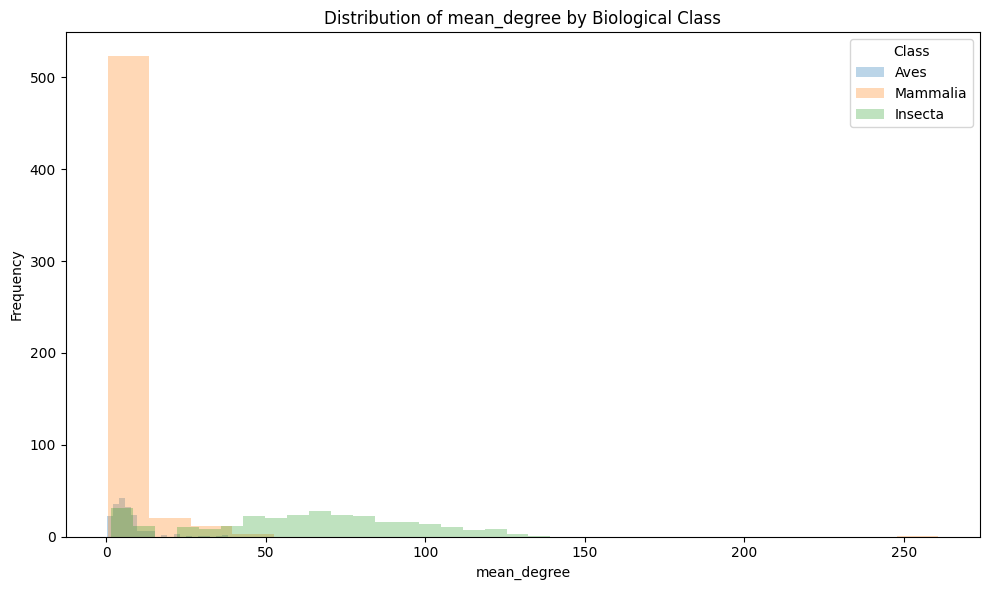

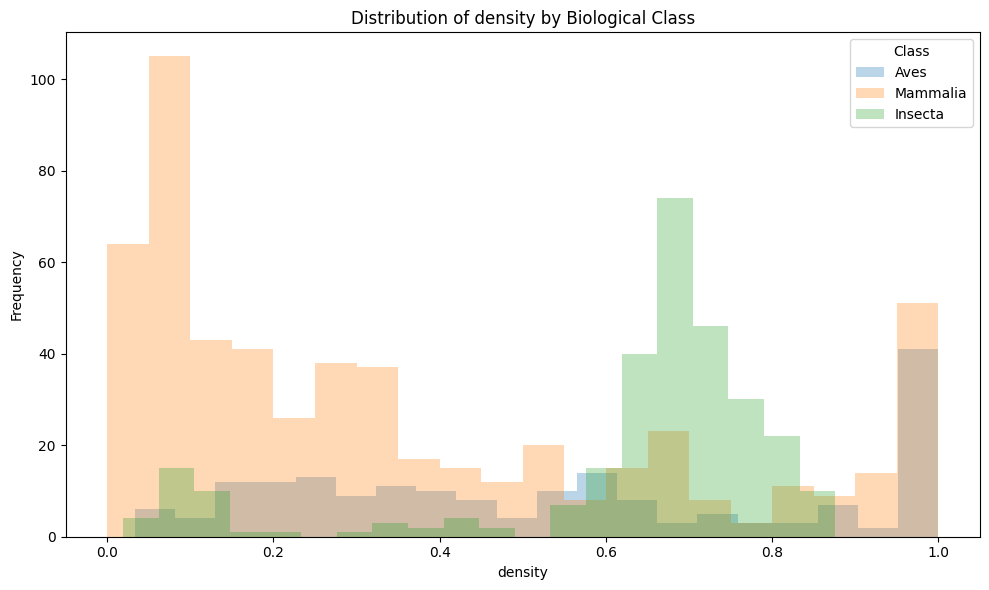

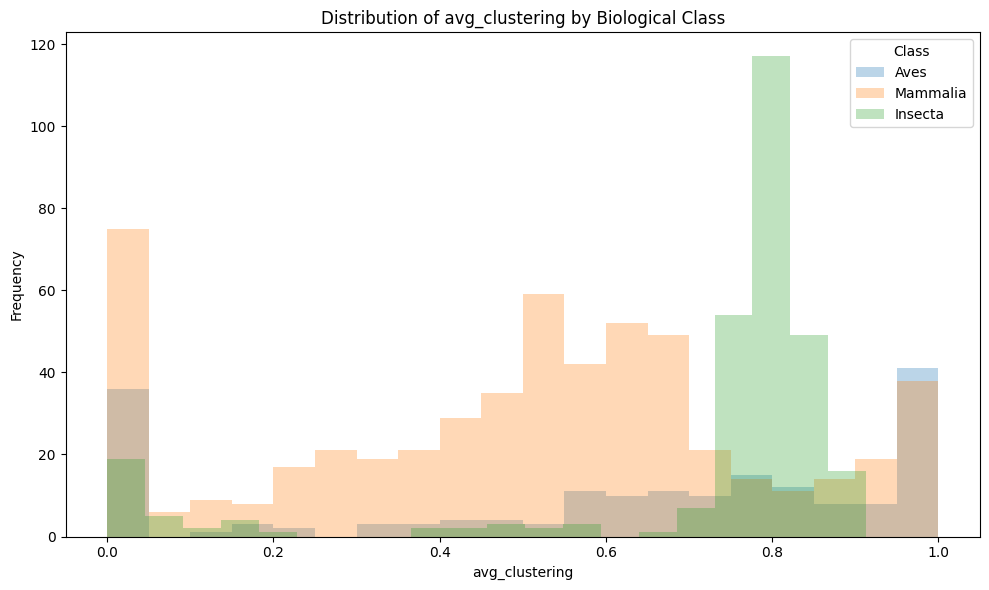

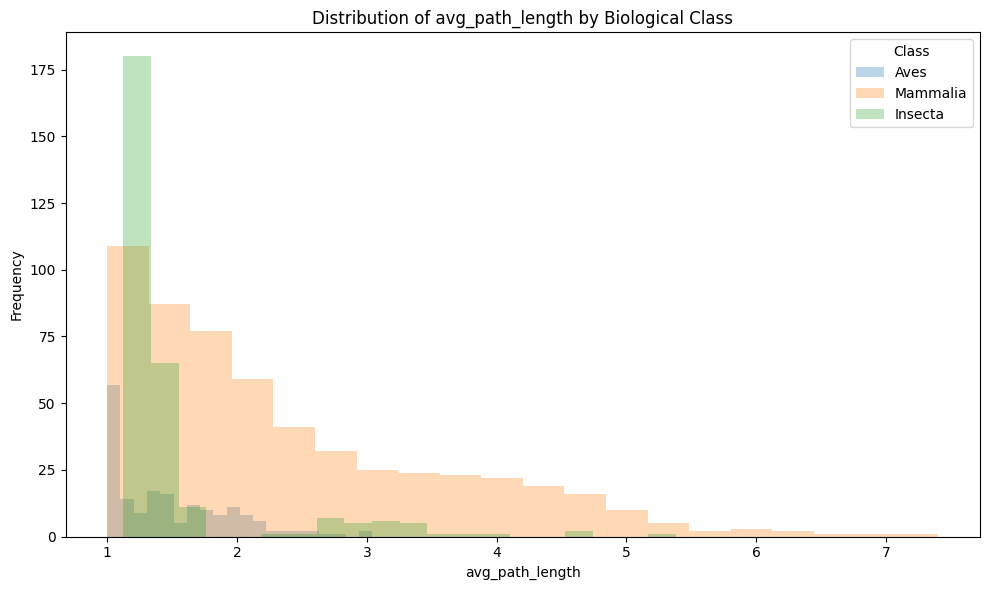

In [33]:
# Histograms of Features by class
features_to_plot = [
    'mean_degree',
    'density',
    'avg_clustering',
    'avg_path_length'
]

classes = feat_df['class'].unique()

classes = ['Aves', 'Mammalia', 'Insecta']

for feature in features_to_plot:

    plt.figure(figsize=(10, 6))

    for cls in classes:

        subset = feat_df[feat_df['class'] == cls]

        plt.hist(
            subset[feature].dropna(),
            bins=20,
            alpha=0.3,
            label=cls
        )

    plt.title(f'Distribution of {feature} by Biological Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Class')

    plt.tight_layout()
    plt.show()

C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels'

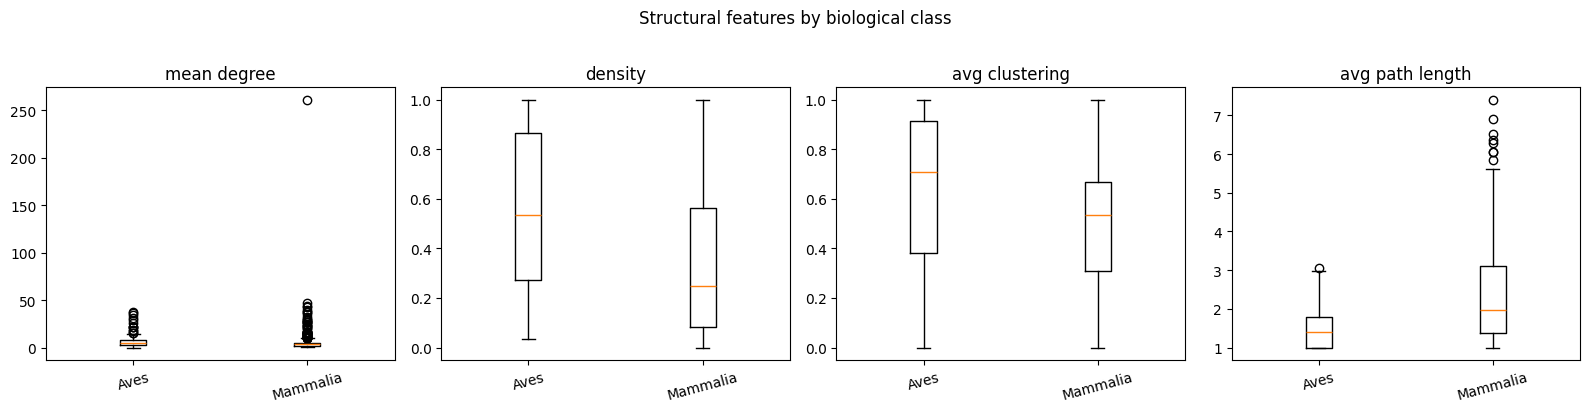

In [37]:
#Box plots of structural features per biological class
features_to_plot = ['mean_degree', 'density', 'avg_clustering', 'avg_path_length']
bio_classes = feat_df['class'].dropna().unique()
#bio_classes = ['Aves', 'Mammalia', 'Insecta']
bio_classes = ['Aves', 'Mammalia']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 4))
for ax, feat in zip(axes, features_to_plot):
    data_per_class = [feat_df[feat_df['class'] == c][feat].dropna().values for c in bio_classes]
    ax.boxplot(data_per_class, labels=bio_classes)
    ax.set_title(feat.replace('_', ' '))
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Structural features by biological class', y=1.02)
plt.tight_layout()
plt.savefig('eda_structural_features.pdf', bbox_inches='tight')
plt.show()

### Features by Interaction Type

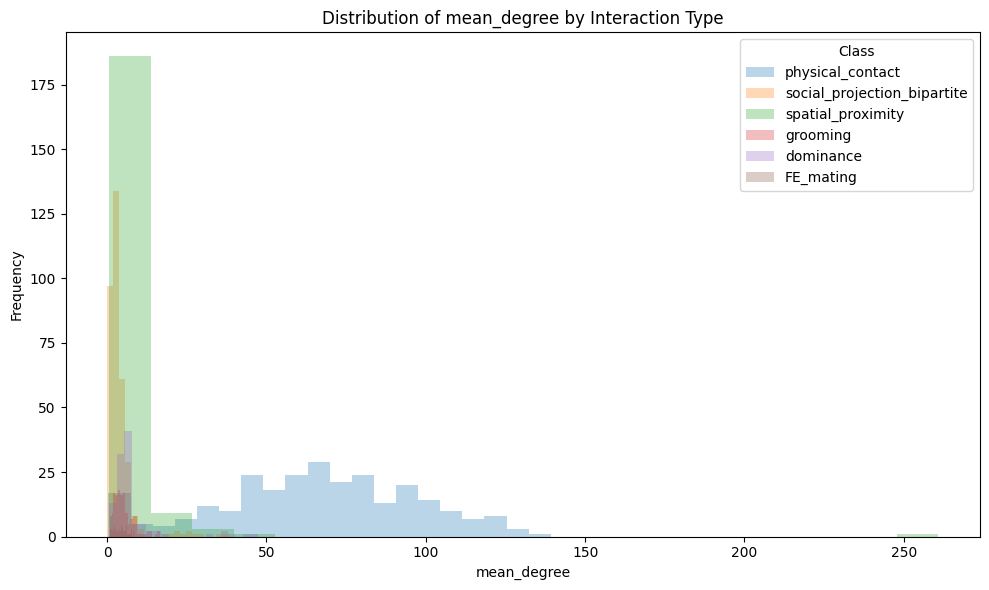

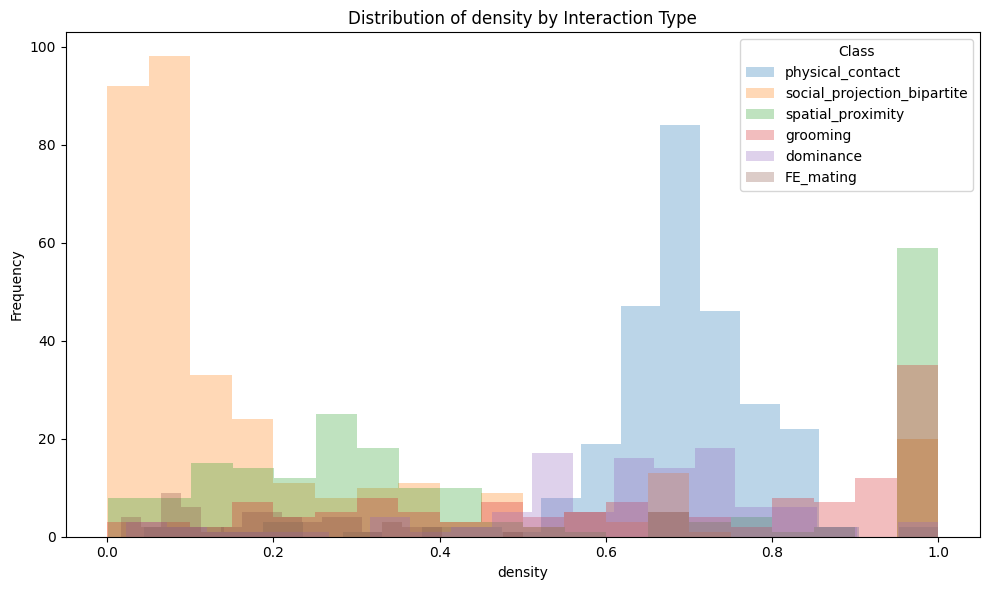

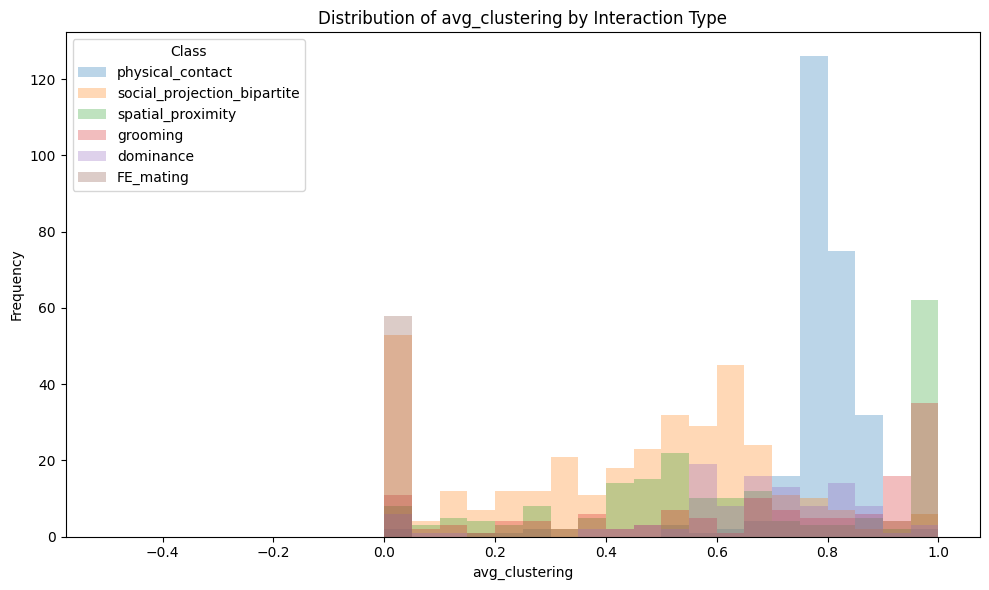

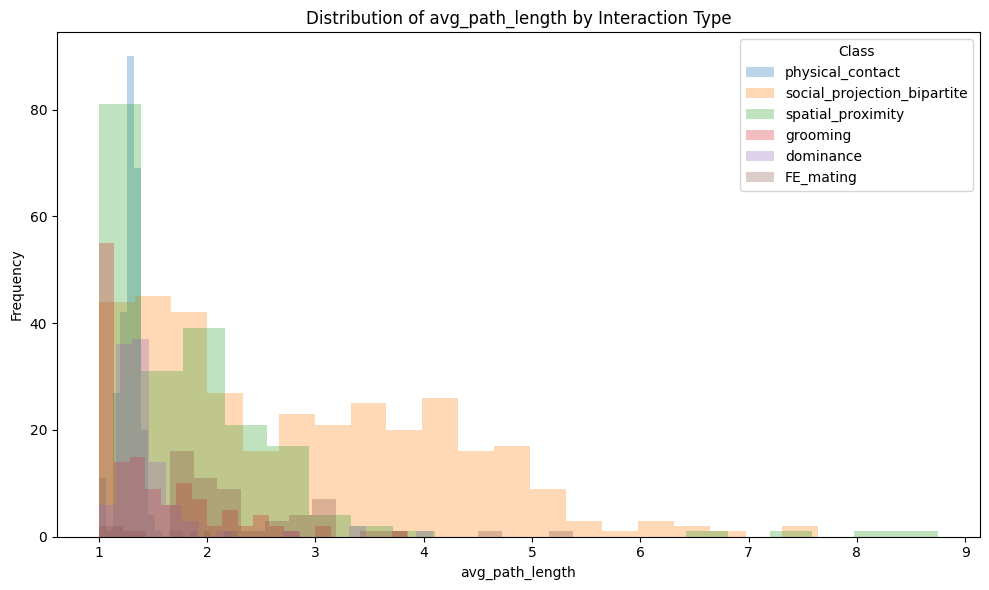

In [35]:
# Histograms of Features by class
features_to_plot = [
    'mean_degree',
    'density',
    'avg_clustering',
    'avg_path_length'
]

interactions = feat_df['interaction_type'].unique()

interactions = ['physical_contact', 'social_projection_bipartite', 'spatial_proximity', 'grooming','dominance','FE_mating']

for feature in features_to_plot:

    plt.figure(figsize=(10, 6))

    for tp in interactions:

        subset = feat_df[feat_df['interaction_type'] == tp]

        plt.hist(
            subset[feature].dropna(),
            bins=20,
            alpha=0.3,
            label=tp
        )

    plt.title(f'Distribution of {feature} by Interaction Type')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Class')

    plt.tight_layout()
    plt.show()

C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\1062315173.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\1062315173.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\1062315173.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_5908\1062315173.py:8: MatplotlibDeprecationWarning: The 'labels' par

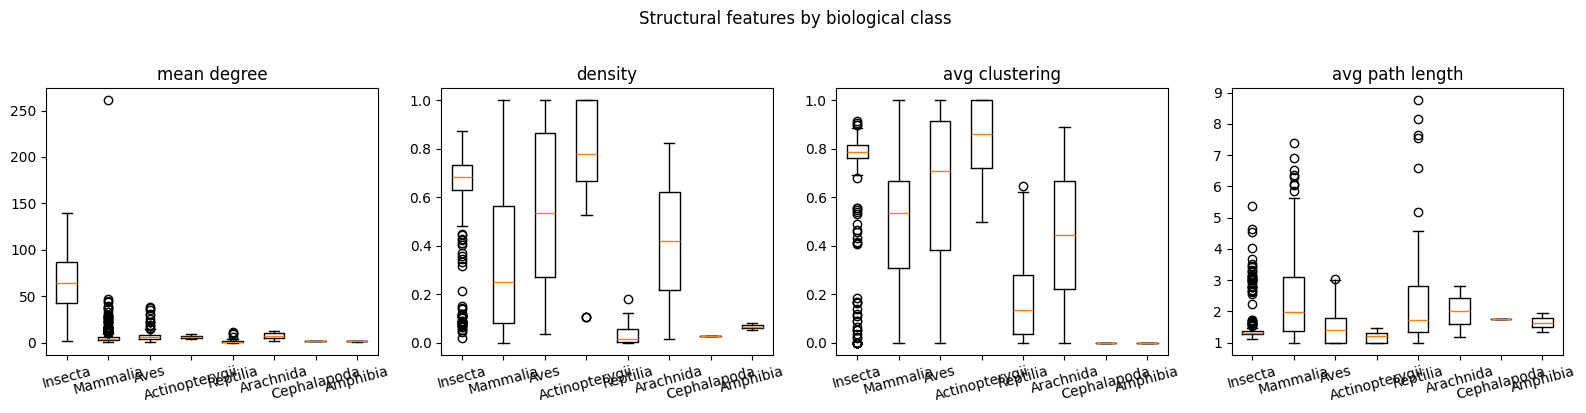

In [62]:
#Box plots of structural features per interaction type
features_to_plot = ['mean_degree', 'density', 'avg_clustering', 'avg_path_length']
bio_classes = feat_df['class'].dropna().unique()

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 4))
for ax, feat in zip(axes, features_to_plot):
    data_per_class = [feat_df[feat_df['class'] == c][feat].dropna().values for c in bio_classes]
    ax.boxplot(data_per_class, labels=bio_classes)
    ax.set_title(feat.replace('_', ' '))
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Structural features by biological class', y=1.02)
plt.tight_layout()
plt.savefig('eda_structural_features.pdf', bbox_inches='tight')
plt.show()

### Graph Visualization

In [66]:
#Graph visualisations per interaction type
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

selected_classes = [
    'Mammalia',
    'Insecta',
    'Aves'
]

filtered_df = info_frame[
    info_frame['interaction_type'].isin(selected_interactions) &
    info_frame['class'].isin(selected_classes) &
    (info_frame['nodes'] > 10) &
    pd.notna(info_frame['avg.edge.strength'])
].copy().rename(columns={'class': 'network_class'})

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

print('Filtered dataset size:', len(filtered_df))
print(filtered_df['interaction_type'].value_counts())

Filtered dataset size: 766
interaction_type
social_projection_bipartite    271
physical_contact               255
spatial_proximity              119
grooming                        52
FE_mating                       41
dominance                       28
Name: count, dtype: int64


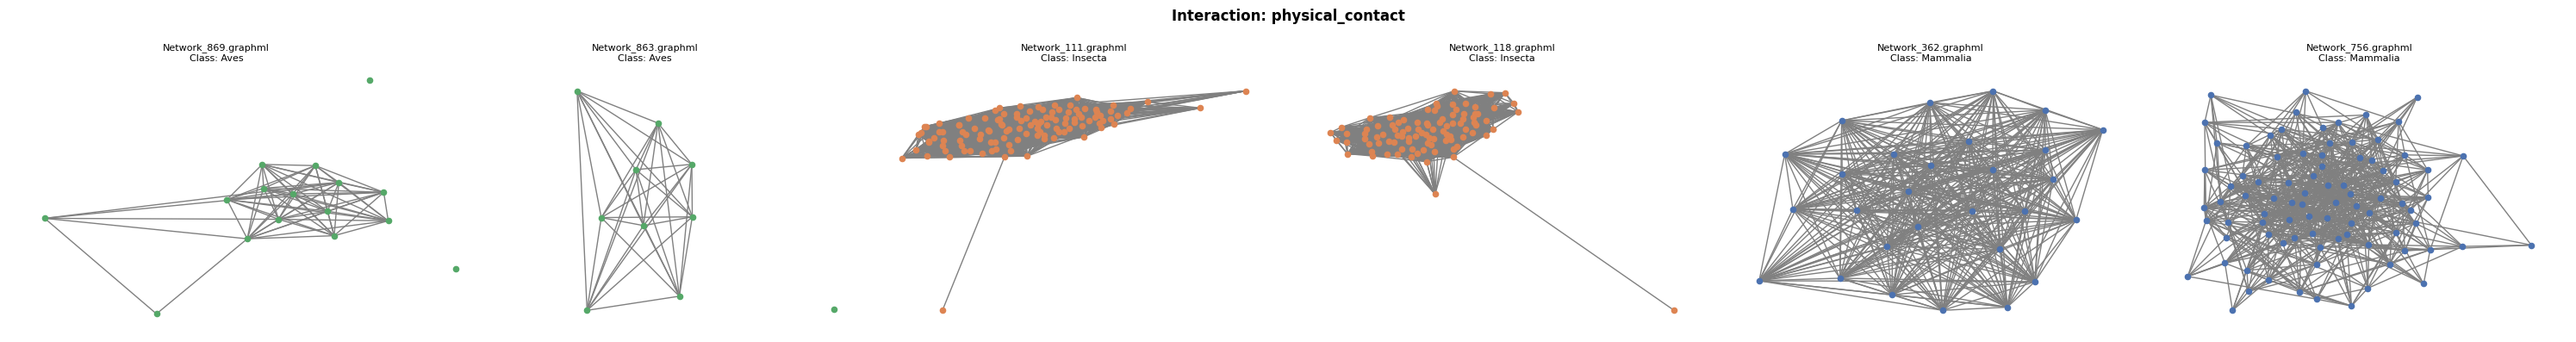

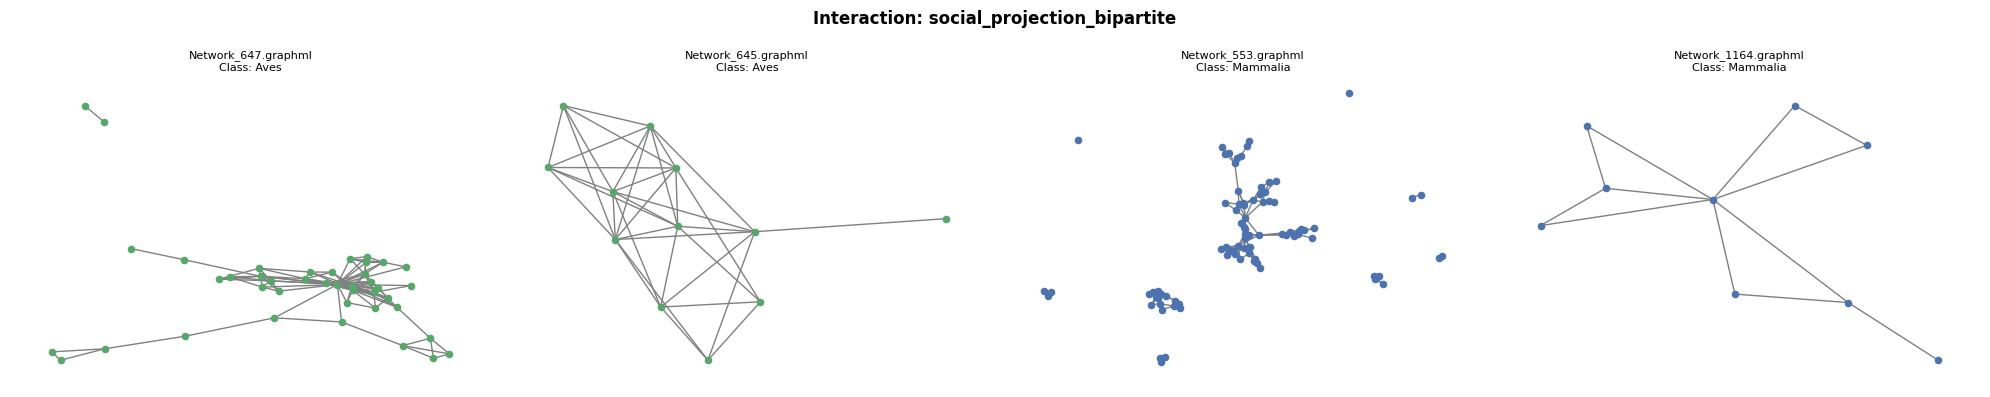

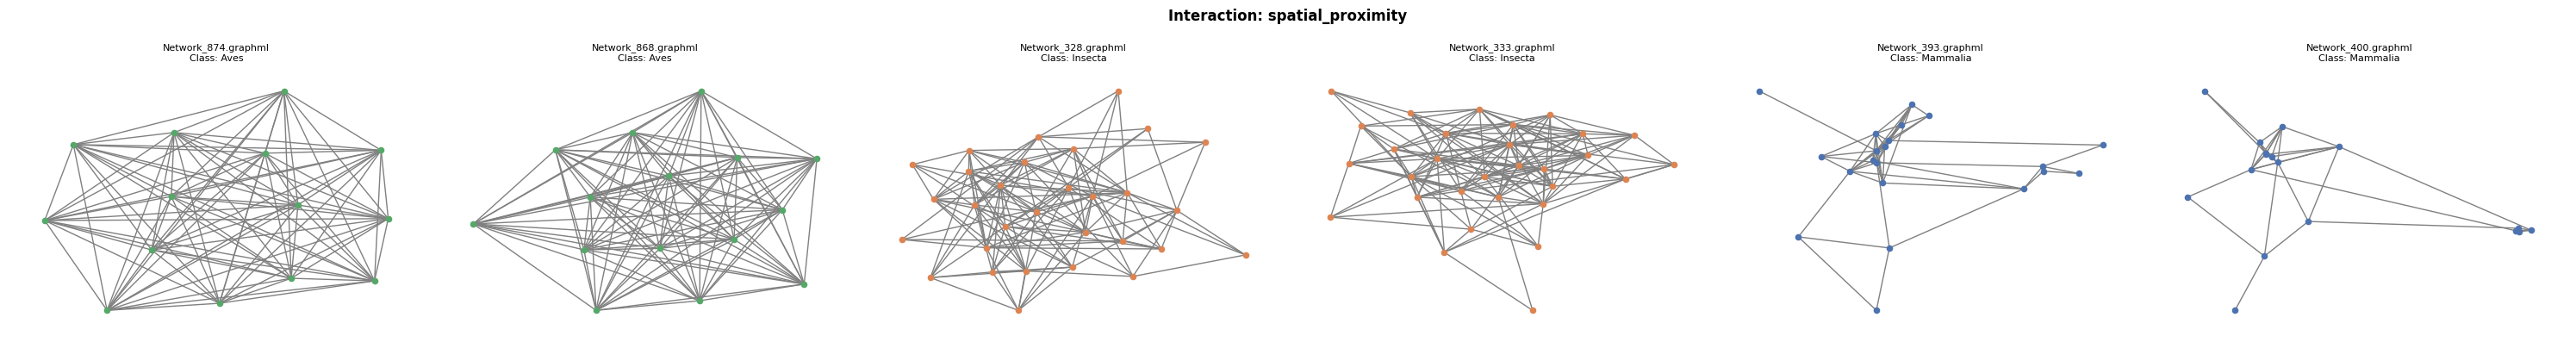

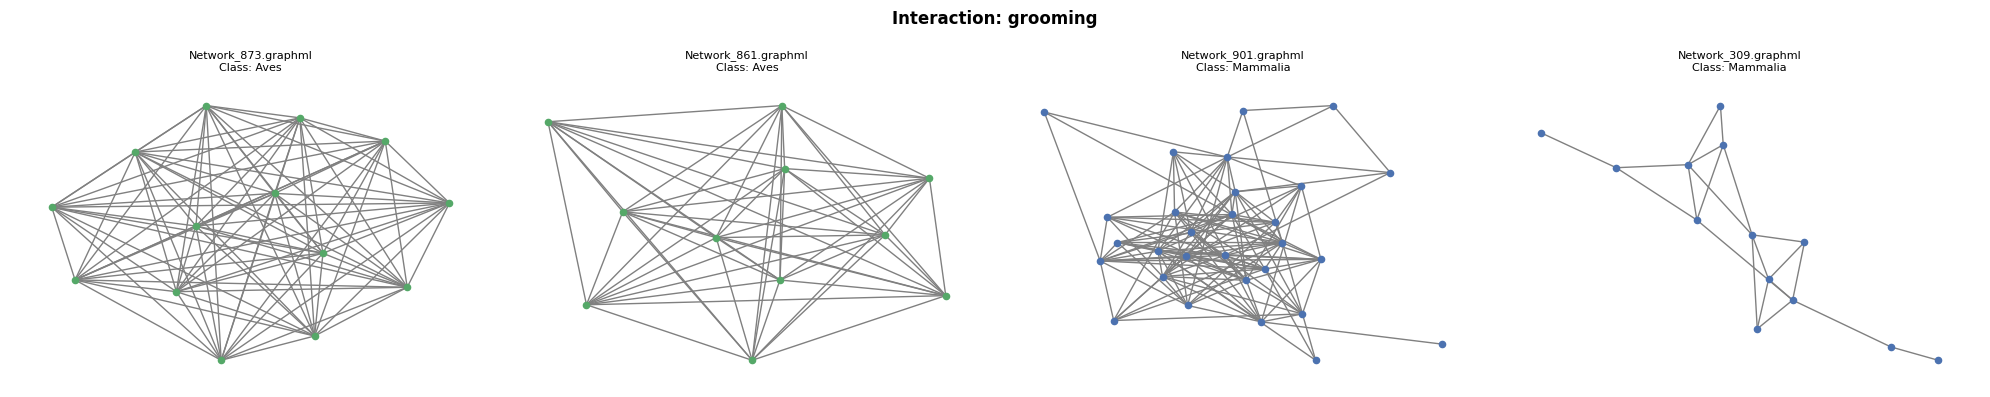

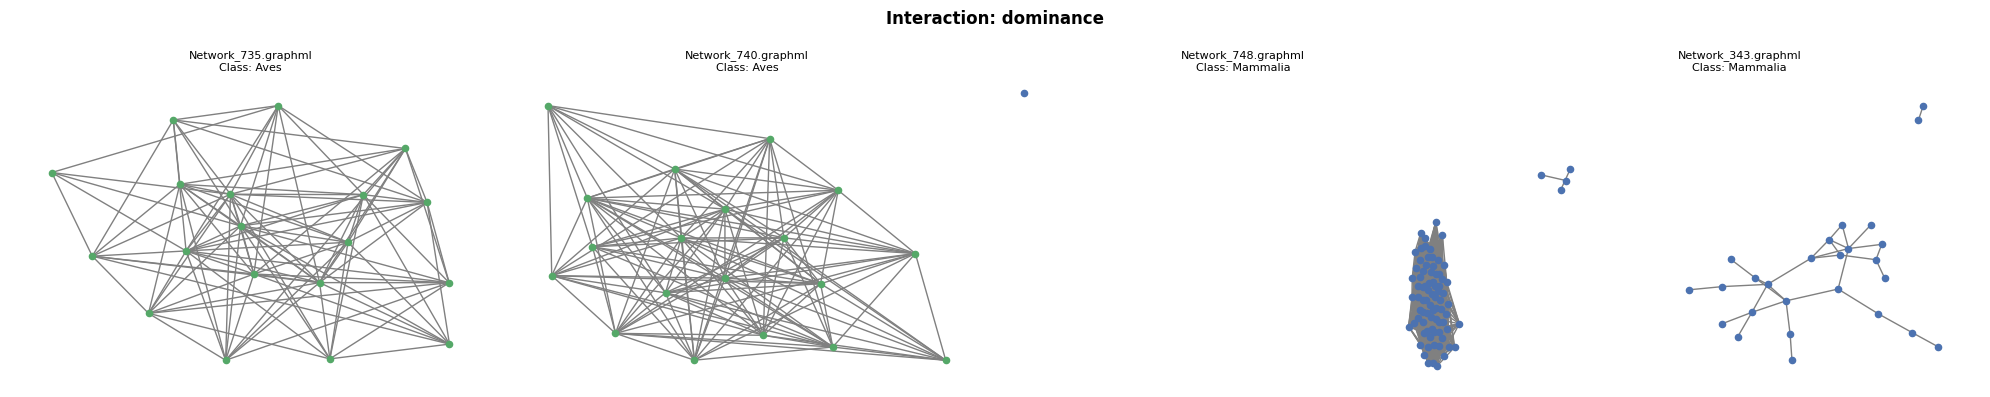

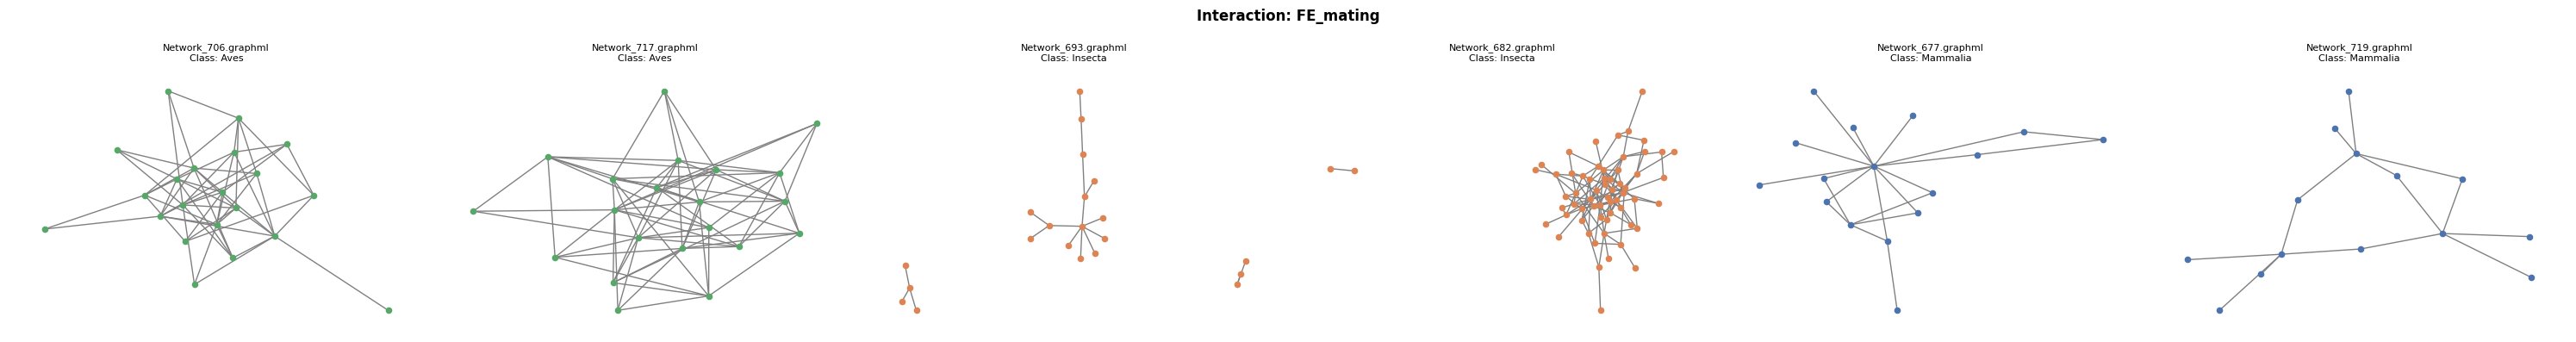

In [83]:
# Plot 2 examples per interaction type, coloured by biological class
samples_per_group = 2
sampled_df = (
    filtered_df
    .groupby(['network_class', 'interaction_type'], group_keys=False)
    .sample(n=samples_per_group, random_state=124)
    .reset_index(drop=True)
)


CLASS_COLORS = {'Mammalia': '#4C72B0', 'Insecta': '#DD8452', 'Aves': '#55A868'}

for interaction in selected_interactions:
    subset = sampled_df[sampled_df['interaction_type'] == interaction]
    if len(subset) == 0:
        continue
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Interaction: {interaction}', fontsize=12, fontweight='bold')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        g = asnr_graphs[row['Network_ID']]
        color = CLASS_COLORS.get(row['network_class'], 'lightgray')
        nx.draw(g, ax=ax, with_labels=False, node_size=20,
                node_color=color, edge_color='gray')
        ax.set_title(f"{row['Network_ID']}\nClass: {row['network_class']}", fontsize=8)
    plt.tight_layout()
    plt.show()

## 3. Dataset Construction

In [84]:
import torch
from torch_geometric.data import Data

# Biological class label mapping (stored alongside interaction label)
bio_class_mapping = {c: i for i, c in enumerate(filtered_df['network_class'].unique())}
print('Biological class mapping:', bio_class_mapping)
print('Interaction type mapping:', interaction_mapping)

def build_dataset(graphs_dict, df_subset):
    """
    Build a list of PyG Data objects.
    Each Data object stores:
      x            — node features: [degree, local_clustering_coeff]
      edge_index   — COO edge list
      interaction_type            — interaction type label (classification target)
      bio_class    — biological class label (for analysis)
      network_id   — string identifier
    """
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict:
            continue
        graph = graphs_dict[key]
        G_und = graph.to_undirected() if graph.is_directed() else graph

        node_mapping = {node: i for i, node in enumerate(G_und.nodes())}

        # Node features: degree + local clustering coefficient
        clustering = nx.clustering(G_und)
        x = torch.tensor(
            [[G_und.degree(node), clustering[node]] for node in G_und.nodes()],
            dtype=torch.float
        )

        # Edge index (undirected — add both directions)
        edges = []
        for u, v in G_und.edges():
            edges.append([node_mapping[u], node_mapping[v]])
            edges.append([node_mapping[v], node_mapping[u]])
        if len(edges) == 0:
            continue  # skip edgeless graphs
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

        interaction_type = torch.tensor([row['interaction_map']], dtype=torch.long)
        bio_label = torch.tensor([bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index, y=interaction_type)
        data.bio_class = bio_label
        data.network_id = key
        dataset.append(data)

    return dataset

print(f'Node feature dim: 2 (degree + clustering coefficient)')

Biological class mapping: {'Insecta': 0, 'Mammalia': 1, 'Aves': 2}
Interaction type mapping: {'physical_contact': 0, 'social_projection_bipartite': 1, 'spatial_proximity': 2, 'grooming': 3, 'dominance': 4, 'FE_mating': 5}
Node feature dim: 2 (degree + clustering coefficient)


## 4. Train / Val / Test Split (Stratified)

In [85]:
from sklearn.model_selection import train_test_split

# First split off test set (15%), then split remainder into train (70%) and val (15%)
train_val_df, test_df = train_test_split(
    filtered_df,
    test_size=0.15,
    stratify=filtered_df['interaction_map'],
    random_state=42,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15 / 0.85,  # ~15% of total
    stratify=train_val_df['interaction_map'],
    random_state=42,
)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')
print('Train interaction counts:')
print(train_df['interaction_type'].value_counts())

train_dataset = build_dataset(asnr_graphs, train_df)
val_dataset   = build_dataset(asnr_graphs, val_df)
test_dataset  = build_dataset(asnr_graphs, test_df)

print(f'\nBuilt {len(train_dataset)} train / {len(val_dataset)} val / {len(test_dataset)} test graphs')

Train: 536  Val: 115  Test: 115
Train interaction counts:
interaction_type
social_projection_bipartite    189
physical_contact               179
spatial_proximity               83
grooming                        36
FE_mating                       29
dominance                       20
Name: count, dtype: int64

Built 536 train / 115 val / 115 test graphs


## 5. Data Augmentation (Minority Class Oversampling)

In [87]:
import copy
import random

def augment_graph_node_drop(data, drop_prob=0.05):
    #Return none if too small
    data_aug = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5:
        return None

    keep_mask = torch.tensor(
        [random.random() > drop_prob for _ in range(num_nodes)],
        dtype=torch.bool
    )
    if keep_mask.sum() < 5:
        return None

    # Filter node features
    data_aug.x = data_aug.x[keep_mask]

    # Filter edges: keep only edges where both endpoints survive
    edge_index = data_aug.edge_index
    edge_mask = keep_mask[edge_index[0]] & keep_mask[edge_index[1]]
    edge_index = edge_index[:, edge_mask]

    # Reindex nodes to be contiguous
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[edge_index]

    return data_aug



def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_minority=3, drop_prob=0.05, seed=124):
    """
    Augment training set by generating extra copies of minority class graphs.
    Majority class is left as-is; minority classes get `copies_per_minority`
    augmented copies added.
    """
    random.seed(seed)
    torch.manual_seed(seed)

    counts = df[target_col].value_counts()
    majority_count = counts.max()
    augmented = list(dataset)

    for data in dataset:
        label = data.y.item()
        if counts[label] < majority_count:
            for _ in range(copies_per_minority):
                aug = augment_graph_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)

    return augmented

def oversample_all(dataset, df, target_col='interaction_map',
                        copies=20, drop_prob=0.05, seed=124):
    """
    Augment training set by generating extra copies of all class graphs.
    """
    random.seed(seed)
    torch.manual_seed(seed)

    counts = df[target_col].value_counts()
    majority_count = counts.max()
    augmented = list(dataset)

    for data in dataset:
        label = data.y.item()
        for _ in range(copies):
            aug = augment_graph_node_drop(data, drop_prob=drop_prob)
            if aug is not None:
                augmented.append(aug)

    return augmented



augmented_train = oversample_all(
    train_dataset, train_df,
    copies=20,
    drop_prob=0.05,
)

print(f'Train before augmentation: {len(train_dataset)}')
print(f'Train after augmentation:  {len(augmented_train)}')

Train before augmentation: 536
Train after augmentation:  10794


## 6. Model Definition

In [88]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [89]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool


class GCNClassifier(nn.Module):
    """
    3-layer GCN with global mean pooling and an MLP classification head.
    Input node features: [degree, local_clustering_coeff] → in_channels=2
    """
    def __init__(self, in_channels=2, hidden_dim=64, num_classes=6, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def encode(self, x, edge_index, batch):
        """Return graph-level embeddings (before classification head)."""
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)

    def forward(self, data):
        emb = self.encode(data.x, data.edge_index, data.batch)
        return self.classifier(emb)

## 7. Training with Validation Monitoring

In [91]:
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Weighted cross-entropy: weight_c = total / (n_classes * count_c)
vc = train_df['interaction_map'].value_counts().sort_index()
class_counts = torch.tensor([vc.get(i, 1) for i in range(len(selected_interactions))], dtype=torch.float)
weights = class_counts.sum() / (len(class_counts) * class_counts)
print('Class weights:', weights.numpy().round(3))

model = GCNClassifier(in_channels=2, hidden_dim=64, num_classes=len(selected_interactions)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for data in loader:
            data = data.to(device)
            if train:
                optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, data.y)
            if train:
                loss.backward()
                optimizer.step()
            preds = out.argmax(dim=1)
            total_loss += loss.item() * data.num_graphs
            correct += (preds == data.y).sum().item()
            total += data.num_graphs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(data.y.cpu().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1


best_val_f1 = 0.0
best_model_state = None
history = []

for epoch in range(1, 100):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
        'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1,
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} F1 {tr_f1:.3f} | '
              f'Val loss {val_loss:.4f} acc {val_acc:.3f} F1 {val_f1:.3f}')

# Restore best model
model.load_state_dict(best_model_state)
print(f'\nBest val macro F1: {best_val_f1:.4f}')

Using device: cpu
Class weights: [0.499 0.473 1.076 2.481 4.467 3.08 ]
Epoch 010 | Train loss 0.8577 acc 0.723 F1 0.609 | Val loss 0.9337 acc 0.713 F1 0.577
Epoch 020 | Train loss 0.7112 acc 0.765 F1 0.675 | Val loss 1.0924 acc 0.548 F1 0.473
Epoch 030 | Train loss 0.5921 acc 0.794 F1 0.722 | Val loss 0.9249 acc 0.661 F1 0.519
Epoch 040 | Train loss 0.5229 acc 0.810 F1 0.746 | Val loss 1.0145 acc 0.643 F1 0.507
Epoch 050 | Train loss 0.4750 acc 0.829 F1 0.771 | Val loss 1.0742 acc 0.643 F1 0.517
Epoch 060 | Train loss 0.4713 acc 0.825 F1 0.767 | Val loss 1.0675 acc 0.652 F1 0.550
Epoch 070 | Train loss 0.4377 acc 0.832 F1 0.780 | Val loss 1.0785 acc 0.652 F1 0.536
Epoch 080 | Train loss 0.4366 acc 0.836 F1 0.785 | Val loss 1.1221 acc 0.643 F1 0.518
Epoch 090 | Train loss 0.4280 acc 0.841 F1 0.791 | Val loss 1.1319 acc 0.661 F1 0.542

Best val macro F1: 0.5880


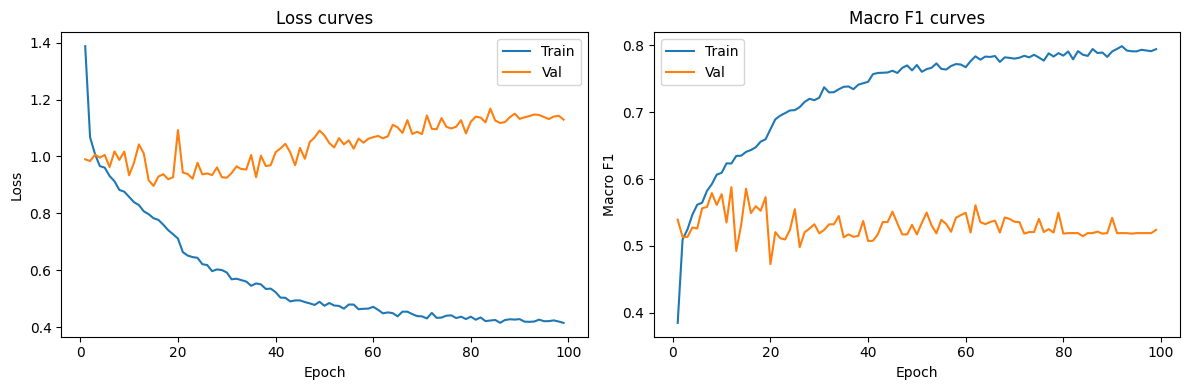

In [92]:
# Training Curves
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['tr_f1'], label='Train')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Macro F1 curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.pdf', bbox_inches='tight')
plt.show()

## 8. Final Evaluation on Test Set

#### After hyperparams

In [93]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels, all_bio = [], [], []
    all_network_ids = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(data.y.cpu().tolist())
            all_bio.extend(data.bio_class.cpu().tolist())
            all_network_ids.extend(data.network_id)

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_bio),
        all_network_ids,
    )


y_pred, y_true, y_bio, net_ids = evaluate_model(model, test_loader, device)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=selected_interactions, zero_division=0))

=== Classification Report ===
                             precision    recall  f1-score   support

           physical_contact       0.92      0.95      0.94        38
social_projection_bipartite       0.94      0.73      0.82        41
          spatial_proximity       0.44      0.22      0.30        18
                   grooming       0.23      0.38      0.29         8
                  dominance       0.08      0.25      0.12         4
                  FE_mating       0.67      1.00      0.80         6

                   accuracy                           0.70       115
                  macro avg       0.55      0.59      0.54       115
               weighted avg       0.76      0.70      0.71       115



## Confusion Matrix

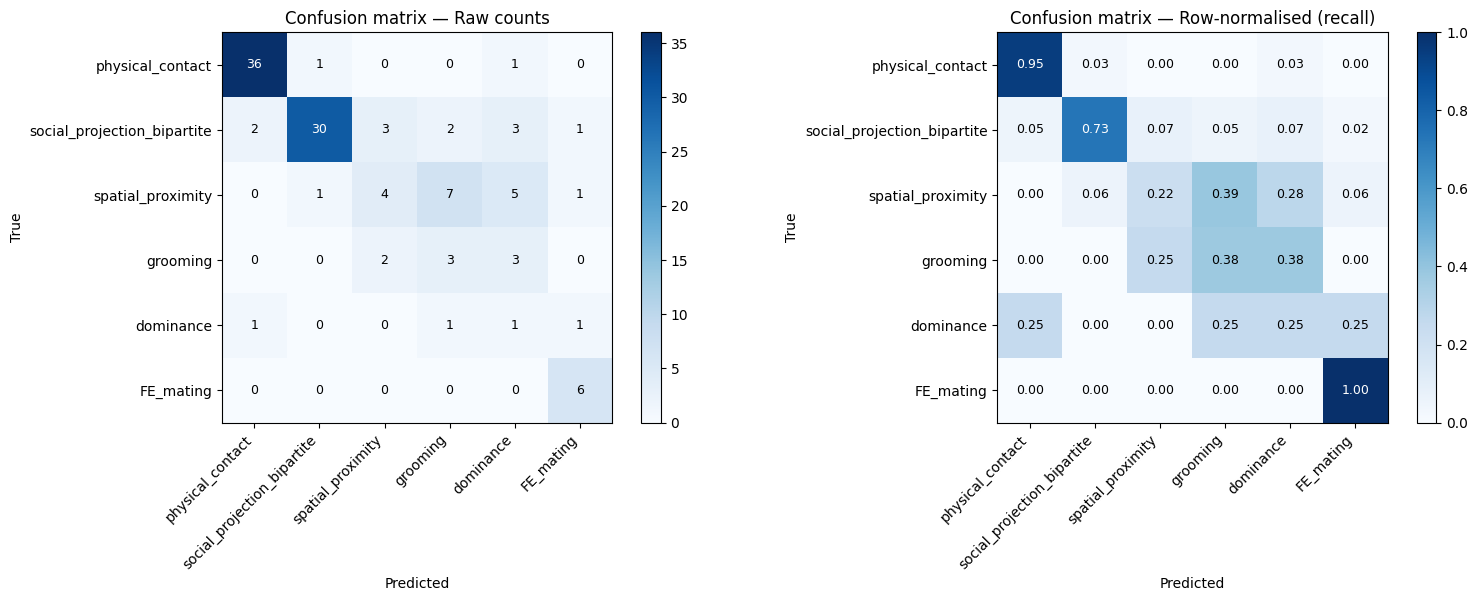

In [94]:

def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion matrix', filename=None):
    cm = confusion_matrix(y_true, y_pred)
    # Normalise rows to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, subtitle in zip(
        axes, [cm, cm_norm], ['d', '.2f'], ['Raw counts', 'Row-normalised (recall)']
    ):
        im = ax.imshow(data, cmap='Blues')
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{title} — {subtitle}')
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, format(data[i, j], fmt),
                        ha='center', va='center',
                        color='white' if data[i, j] > data.max() * 0.6 else 'black',
                        fontsize=9)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    plt.show()
    return cm


cm = plot_confusion_matrix(y_true, y_pred, selected_interactions,
                           filename='confusion_matrix.pdf')

## 9. Biological Analysis
Cross-tabulate prediction accuracy by biological class and interaction type.

In [95]:
# Build a results DataFrame for the test set
bio_class_inv = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}

results_df = pd.DataFrame({
    'network_id': net_ids,
    'true_interaction': [interaction_inv[i] for i in y_true],
    'pred_interaction': [interaction_inv[i] for i in y_pred],
    'bio_class': [bio_class_inv.get(i, 'Unknown') for i in y_bio],
    'correct': y_pred == y_true,
})

print('Accuracy by biological class:')
print(results_df.groupby('bio_class')['correct'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'correct', 'count': 'total', 'mean': 'accuracy'}
))

Accuracy by biological class:
           correct  total  accuracy
bio_class                          
Aves             7     15  0.466667
Insecta         39     40  0.975000
Mammalia        34     60  0.566667


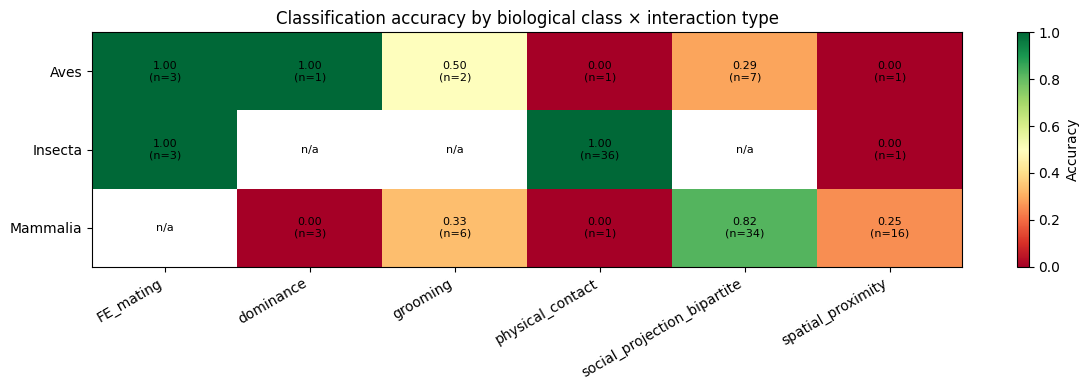

In [96]:
# --- Heatmap: accuracy per (biological class x interaction type) ---
acc_pivot = results_df.pivot_table(
    index='bio_class',
    columns='true_interaction',
    values='correct',
    aggfunc='mean'
)

count_pivot = results_df.pivot_table(
    index='bio_class',
    columns='true_interaction',
    values='correct',
    aggfunc='count'
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(acc_pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(acc_pivot.columns)))
ax.set_yticks(range(len(acc_pivot.index)))
ax.set_xticklabels(acc_pivot.columns, rotation=30, ha='right')
ax.set_yticklabels(acc_pivot.index)
ax.set_title('Classification accuracy by biological class × interaction type')

for i in range(len(acc_pivot.index)):
    for j in range(len(acc_pivot.columns)):
        val = acc_pivot.values[i, j]
        n = count_pivot.values[i, j] if not np.isnan(count_pivot.values[i, j]) else 0
        label = f'{val:.2f}\n(n={int(n)})' if not np.isnan(val) else 'n/a'
        ax.text(j, i, label, ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.savefig('bio_class_accuracy_heatmap.pdf', bbox_inches='tight')
plt.show()

In [97]:
results_with_feats = results_df.merge(
    feat_df[['Network_ID', 'mean_degree', 'density', 'avg_clustering', 'avg_path_length']],
    left_on='network_id', right_on='Network_ID', how='left'
)

print('Structural features — correctly classified vs misclassified:')
print(results_with_feats.groupby('correct')[['mean_degree', 'density', 'avg_clustering']].median())

Structural features — correctly classified vs misclassified:
         mean_degree   density  avg_clustering
correct                                       
False       6.990741  0.222112        0.550241
True        6.257840  0.557851        0.672392


## 10. Embedding Visualisation

In [98]:
# Extract graph-level embeddings from the test set
model.eval()
embeddings, labels, bio_labels = [], [], []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        emb = model.encode(data.x, data.edge_index, data.batch)
        embeddings.append(emb.cpu().numpy())
        labels.append(data.y.cpu().numpy())
        bio_labels.append(data.bio_class.cpu().numpy())

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)
bio_labels = np.concatenate(bio_labels)

C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


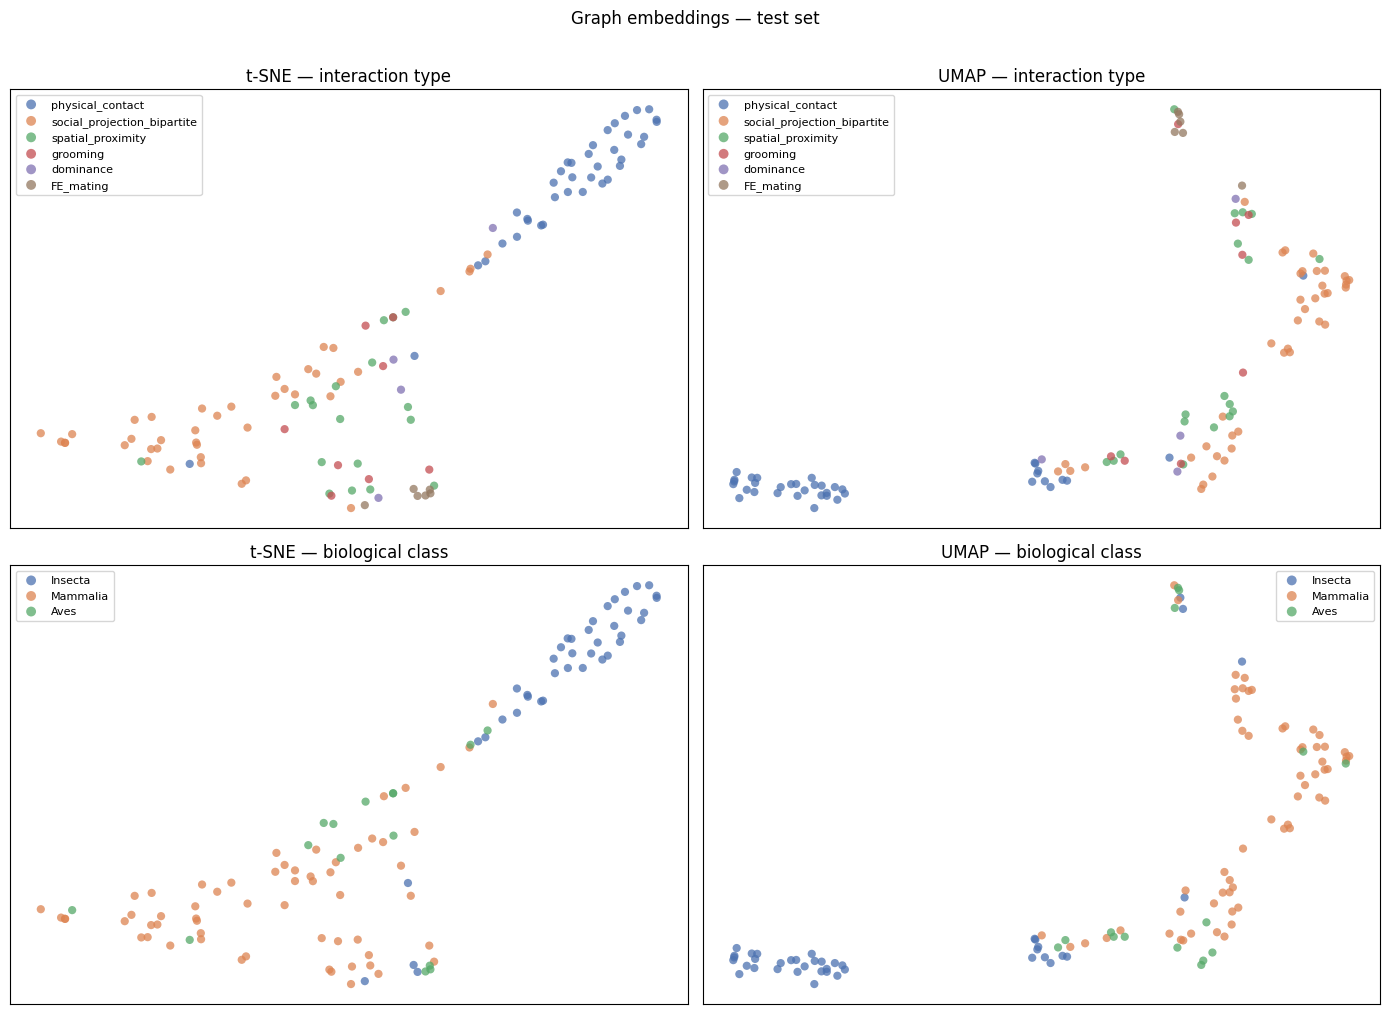

In [99]:
from sklearn.manifold import TSNE

# Try UMAP first; fall back to t-SNE if umap-learn not installed
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords_umap = reducer.fit_transform(embeddings)
    use_umap = True
except ImportError:
    print('umap-learn not installed — using t-SNE only. Install with: pip install umap-learn')
    use_umap = False

coords_tsne = TSNE(n_components=2, perplexity=min(30, len(embeddings) - 1),
                   random_state=42).fit_transform(embeddings)


def scatter_embeddings(coords, color_labels, color_names, title, ax, markers=None):
    palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
    for i, name in enumerate(color_names):
        mask = color_labels == i
        marker = markers[i] if markers else 'o'
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=name, color=palette[i % len(palette)],
                   alpha=0.75, s=35, marker=marker, edgecolors='none')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(fontsize=8, markerscale=1.2)


n_plots = 2 if use_umap else 1
fig, axes = plt.subplots(2, n_plots, figsize=(7 * n_plots, 10))
if n_plots == 1:
    axes = axes.reshape(-1, 1)

bio_names = [bio_class_inv[i] for i in sorted(bio_class_inv)]
int_names = selected_interactions

# Row 0: coloured by interaction type
scatter_embeddings(coords_tsne, labels, int_names, 't-SNE — interaction type', axes[0, 0])
if use_umap:
    scatter_embeddings(coords_umap, labels, int_names, 'UMAP — interaction type', axes[0, 1])

# Row 1: coloured by biological class
scatter_embeddings(coords_tsne, bio_labels, bio_names, 't-SNE — biological class', axes[1, 0])
if use_umap:
    scatter_embeddings(coords_umap, bio_labels, bio_names, 'UMAP — biological class', axes[1, 1])

plt.suptitle('Graph embeddings — test set', y=1.01)
plt.tight_layout()
plt.savefig('embeddings.pdf', bbox_inches='tight')
plt.show()

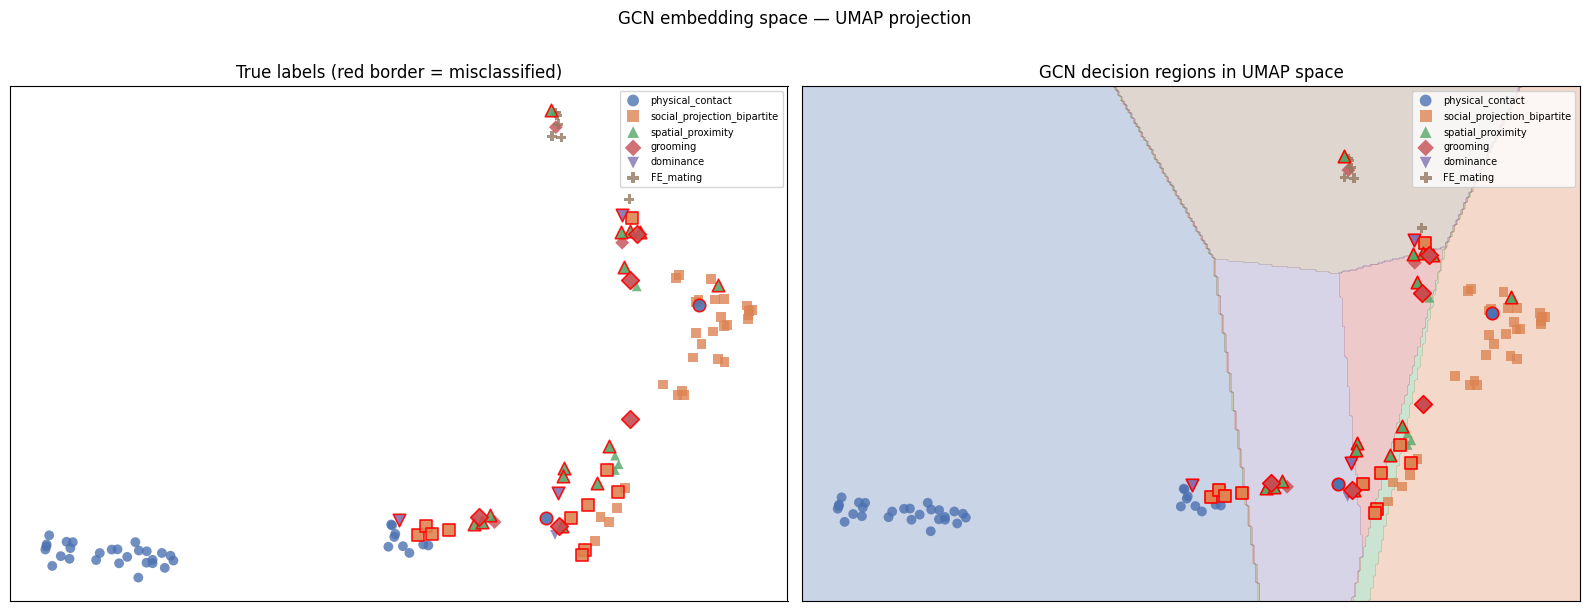

In [100]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Assumes coords_umap, labels (true), y_pred, selected_interactions already exist

palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
markers = ['o', 's', '^', 'D', 'v', 'P']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: true vs predicted, misclassified highlighted ---
ax = axes[0]
correct_mask = y_pred == labels

for i, name in enumerate(selected_interactions):
    mask = (labels == i) & correct_mask
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.8, s=50, label=name, edgecolors='none')

# Misclassified: show true class colour, red border
for i, name in enumerate(selected_interactions):
    mask = (labels == i) & ~correct_mask
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.9, s=80, edgecolors='red', linewidths=1.2)

ax.set_title('True labels (red border = misclassified)')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7, markerscale=1.2)

# --- Plot 2: decision regions in UMAP space ---
ax = axes[1]

# Fit logistic regression in 2D UMAP space
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(coords_umap, y_pred)  # fit on predicted labels = GCN's view of the world

# Create a meshgrid covering the UMAP space
x_min, x_max = coords_umap[:, 0].min() - 1, coords_umap[:, 0].max() + 1
y_min, y_max = coords_umap[:, 1].min() - 1, coords_umap[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Shade background by decision region
cmap_bg = ListedColormap([c + '40' for c in palette[:len(selected_interactions)]])
ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg,
            levels=np.arange(-0.5, len(selected_interactions)))

# Overlay actual points coloured by true label
for i, name in enumerate(selected_interactions):
    mask = labels == i
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               alpha=0.8, s=50, label=name, edgecolors='none')

# Red borders on misclassified
for i in range(len(selected_interactions)):
    mask = (labels == i) & (y_pred != labels)
    ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
               color=palette[i], marker=markers[i],
               s=80, edgecolors='red', linewidths=1.2)

ax.set_title("GCN decision regions in UMAP space")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=7, markerscale=1.2)

plt.suptitle('GCN embedding space — UMAP projection', y=1.01)
plt.tight_layout()
plt.savefig('umap_decision_regions.pdf', bbox_inches='tight')
plt.show()